# 1. Read .snx file as a VCM; read .gfc file as ground truth

In [1]:
import pathlib

import cartopy
import numpy as np

import sagea
from sagea import SHC

"""define paths"""
date_month = "2008-03"
lmax = 60

path_snx = pathlib.Path(f"/Volumes/ShuhaoWork/GRACE_NEQ/ITSG_SINEX_n96/ITSG-Grace2018_n96_{date_month}.snx")
path_his = pathlib.Path(f"/Volumes/ShuhaoWork/ESM_monthly_mean/HIS_n60/esm_HIS_monthly_{date_month}.gfc")

vcm, _ = sagea.io.read_sinex_cov(path_snx, lmax=lmax)  # this may take a few tens of seconds
shc_truth = SHC.io.from_gfc(path_his, lmax=lmax, key="gfc")


# 2. Generate noise samples from a vcm, and add them on the ground truth

In [2]:
nsample = 100

shc_with_noise = SHC.generate.normal_from_vcm(vcm, nsample=nsample, mean=shc_truth)

# 3. postprocessing to EWH fields

In [11]:
shc_filtered = shc_with_noise.filter.gaussian(300)
shc_filtered_ewh = shc_filtered.convert(from_type="Geopotential", to_type="EWH")

grid = shc_filtered_ewh.to_grid(grid_space=1)

# 4. Statistics

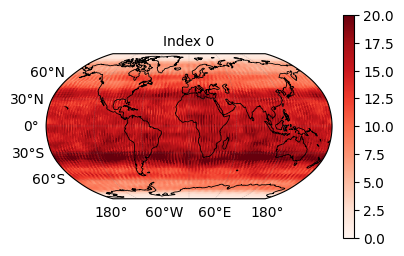

(<Figure size 450x340 with 2 Axes>,
 array([[<GeoAxes: title={'center': 'Index 0'}>]], dtype=object))

In [13]:
import cartopy

std_grid_value = np.std(grid.value, axis=0)
grid_std = sagea.GRD(std_grid_value * 100, lat=grid.lat, lon=grid.lon)  # EWH in unit [cm]

grid_std.plot(
    vmin=0, vmax=20,
    projection=cartopy.crs.Robinson(),
    cmap="Reds",
)